# Info
Name:  

    GV_platform_parameterization

Purpose:  

    Derive platform parameterization values for the GV (HIAPER) aircraft
    from actual ACCLIP flight data: ground speed vs altitude, vertical speed,
    bank angle in turns, cruise altitude, and speed-altitude slope.
    Used to fill in the 'gv' entry in the platform configuration file.
  
Input:

    /data2/INSPYRE/ACCLIP-10SEC_GV_R0_COMPOSITE.nc

Output:
   
    plots, printed platform parameter values
  
Keywords:

    none
  
Dependencies:

    - numpy
    - scipy
    - matplotlib
    - netCDF4

Needed Files:

  - /data2/INSPYRE/ACCLIP-10SEC_GV_R0_COMPOSITE.nc
    
History:

    Written: Samuel LeBlanc, Santa Cruz, CA, 2026-06-02
    

# Prepare the python environment

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4 as nc

In [2]:
%matplotlib inline

# Load the ACCLIP GV composite file

In [3]:
fp = '/data2/INSPYRE/ACCLIP-10SEC_GV_R0_COMPOSITE.nc'
f  = nc.Dataset(fp)
print(f'Opened: {fp}')
print(f'Project: {f.Project_Name}  Aircraft: {f.Aircraft_Type}  Tail: {f.Aircraft_Tail}')
print(f'Flights: {f.Flights}')

Opened: /data2/INSPYRE/ACCLIP-10SEC_GV_R0_COMPOSITE.nc
Project: ACCLIP  Aircraft: GV  Tail: N677F
Flights: rf01,rf02,rf03,rf04,rf05,rf06,rf07,rf08,rf09,rf10,rf11,rf12,rf13,rf14


In [4]:
FILL = -99999.0

def load_masked(var_name):
    """Load variable, replace fill with NaN."""
    raw = f.variables[var_name][:].astype(float)
    raw[raw <= FILL * 0.9] = np.nan
    return raw

alt     = load_masked('GGALT')    # GPS altitude MSL [m]
gspd    = load_masked('GGSPD')    # GPS ground speed  [m/s]
vspd    = load_masked('GGVSPD')   # GPS vertical speed [m/s]
roll    = load_masked('ROLL')     # IRS roll (bank) angle [deg]
fltnum  = f.variables['Flight_Number'][:].astype(int)
time_s  = load_masked('Mid_Time_UTC')   # UTC seconds since 2022-08-30

print(f'Total records: {len(alt)}')
print(f'Altitude  [m]   : {np.nanmin(alt):.0f} – {np.nanmax(alt):.0f}')
print(f'Gnd speed [m/s] : {np.nanmin(gspd):.1f} – {np.nanmax(gspd):.1f}')
print(f'Vert speed[m/s] : {np.nanmin(vspd):.2f} – {np.nanmax(vspd):.2f}')
print(f'Roll      [deg] : {np.nanmin(roll):.1f} – {np.nanmax(roll):.1f}')
print(f'Flights         : {np.unique(fltnum)}')

Total records: 31694
Altitude  [m]   : 14 – 15714
Gnd speed [m/s] : 0.0 – 294.8
Vert speed[m/s] : -30.10 – 31.81
Roll      [deg] : -31.6 – 30.5
Flights         : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


# Filter to in-flight data and classify phases

In [5]:
# keep only records that look like real flight (above ground, reasonable speed)
in_flight = (alt > 100.0) & (gspd > 30.0) & np.isfinite(alt) & np.isfinite(gspd) & np.isfinite(vspd)

alt_f  = alt[in_flight]
gspd_f = gspd[in_flight]
vspd_f = vspd[in_flight]
roll_f = roll[in_flight]
flt_f  = fltnum[in_flight]

# phase classification thresholds
VS_CLIMB   =  1.5   # m/s  (~300 ft/min)
VS_DESCENT = -1.5

phase = np.where(vspd_f >  VS_CLIMB,   'climb',
        np.where(vspd_f <  VS_DESCENT,  'descent', 'cruise'))

for ph in ['cruise', 'climb', 'descent']:
    mask = phase == ph
    print(f'{ph:8s}: {mask.sum():5d} pts,  '
          f'alt {np.nanpercentile(alt_f[mask],5):.0f}–{np.nanpercentile(alt_f[mask],95):.0f} m,  '
          f'gspd {np.nanmedian(gspd_f[mask]):.1f} m/s median')

cruise  : 23661 pts,  alt 3879–14897 m,  gspd 235.7 m/s median
climb   :  4358 pts,  alt 1741–14626 m,  gspd 232.4 m/s median
descent :  3456 pts,  alt 496–14395 m,  gspd 211.4 m/s median


/home/sam/mambaforge/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/sam/mambaforge/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


# Figure 1 – Flight profile: altitude and ground speed vs time (one example flight)

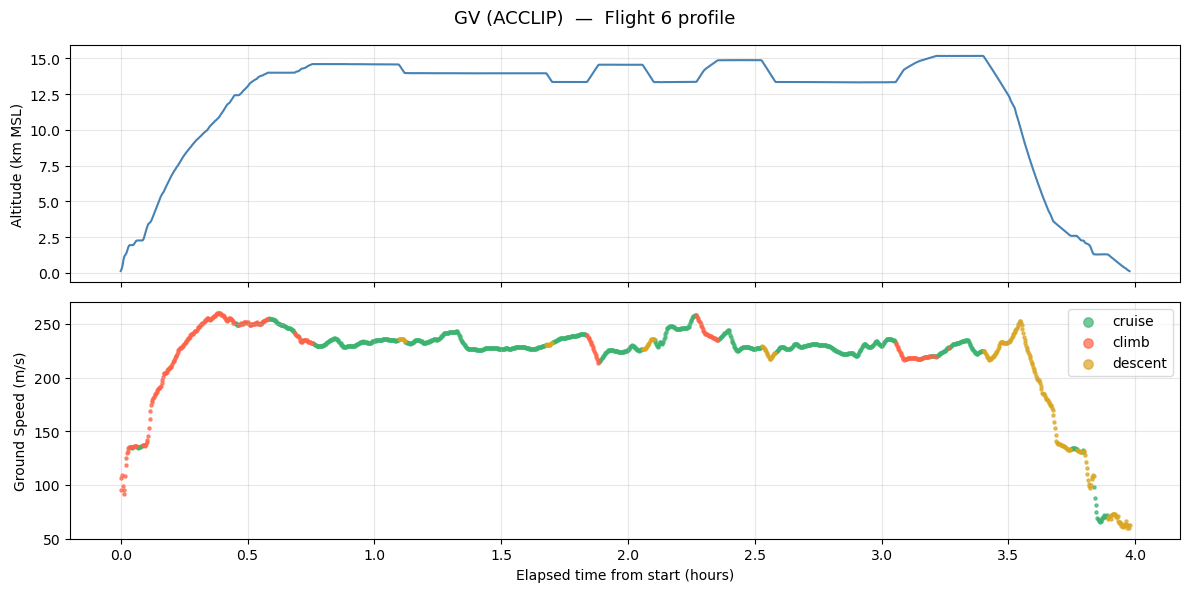

In [6]:
# pick flight 6 as a representative long flight
ex_flt = 6
m = (flt_f == ex_flt)

t_h = (time_s[in_flight][m] - np.nanmin(time_s[in_flight][m])) / 3600.0

COLORS = {'climb': 'tomato', 'cruise': 'mediumseagreen', 'descent': 'goldenrod'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle(f'GV (ACCLIP)  —  Flight {ex_flt} profile', fontsize=13)

ax1.plot(t_h, alt_f[m] / 1000.0, color='steelblue', lw=1.5)
ax1.set_ylabel('Altitude (km MSL)')
ax1.grid(True, alpha=0.3)

for ph in ['cruise', 'climb', 'descent']:
    sel = m & (phase == ph)
    t_ph = (time_s[in_flight][sel] - np.nanmin(time_s[in_flight][m])) / 3600.0
    ax2.scatter(t_ph, gspd_f[sel], s=5, color=COLORS[ph], label=ph, alpha=0.7)

ax2.set_ylabel('Ground Speed (m/s)')
ax2.set_xlabel('Elapsed time from start (hours)')
ax2.legend(markerscale=3, framealpha=0.7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GV_profile_flight{}.png'.format(ex_flt), dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 – Ground speed vs altitude (all flights)

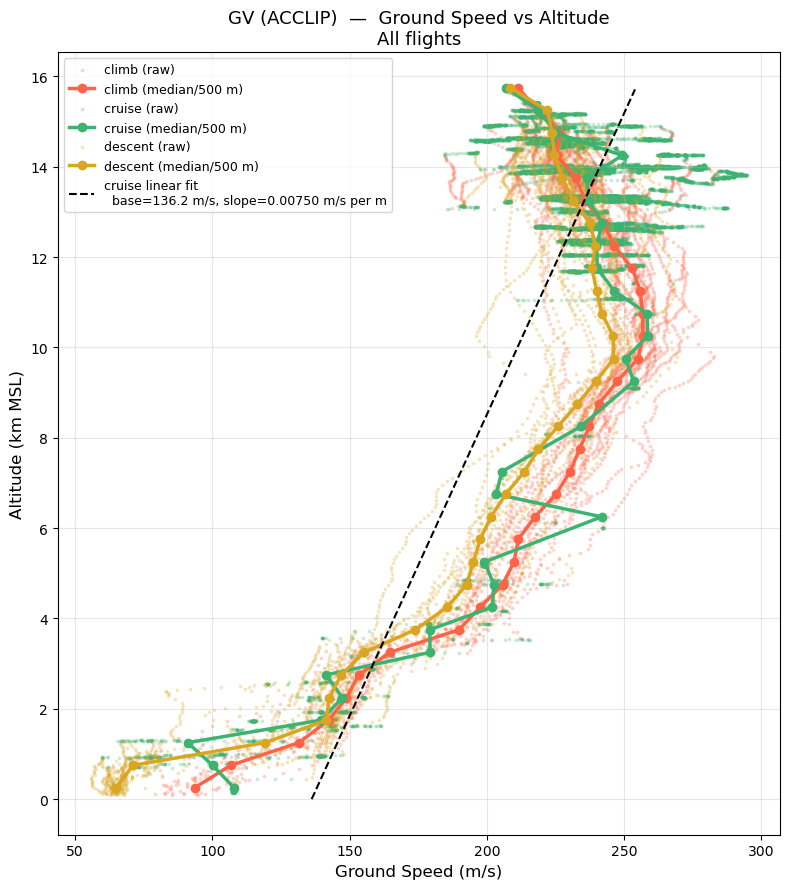

Cruise linear fit: base_speed=136.18 m/s,  speed_per_alt=0.007497 m/s per m
  R = 0.727


In [7]:
ALT_BINS = np.arange(0, 16001, 500)  # 500 m bins

def binned_med(x, y, bins):
    """Median of y in each altitude bin, returning (bin centres, medians)."""
    from scipy.stats import binned_statistic
    stat, edges, _ = binned_statistic(x, y, statistic='median', bins=bins)
    centres = 0.5 * (edges[:-1] + edges[1:])
    ok = np.isfinite(stat)
    return centres[ok], stat[ok]

fig, ax = plt.subplots(figsize=(8, 9))

for ph in ['climb', 'cruise', 'descent']:
    mask = phase == ph
    ax.scatter(gspd_f[mask], alt_f[mask] / 1000.0,
               s=3, alpha=0.2, color=COLORS[ph], label=f'{ph} (raw)')
    if mask.sum() > 20:
        ac, gc = binned_med(alt_f[mask], gspd_f[mask], ALT_BINS)
        ax.plot(gc, ac / 1000.0,
                color=COLORS[ph], lw=2.5, marker='o', ms=6,
                label=f'{ph} (median/500 m)')

# linear fit to cruise phase for parameterization
cruise_mask = phase == 'cruise'
slope, intercept, r, p, se = st.linregress(alt_f[cruise_mask], gspd_f[cruise_mask])
alt_fit = np.array([0, alt_f[cruise_mask].max()])
ax.plot(intercept + slope * alt_fit, alt_fit / 1000.0,
        'k--', lw=1.5, label=f'cruise linear fit\n  base={intercept:.1f} m/s, slope={slope:.5f} m/s per m')

ax.set_xlabel('Ground Speed (m/s)', fontsize=12)
ax.set_ylabel('Altitude (km MSL)', fontsize=12)
ax.set_title('GV (ACCLIP)  —  Ground Speed vs Altitude\nAll flights', fontsize=13)
ax.legend(framealpha=0.8, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GV_gspd_vs_alt.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Cruise linear fit: base_speed={intercept:.2f} m/s,  speed_per_alt={slope:.6f} m/s per m')
print(f'  R = {r:.3f}')

# Figure 3 – Vertical speed vs altitude (climb and descent)

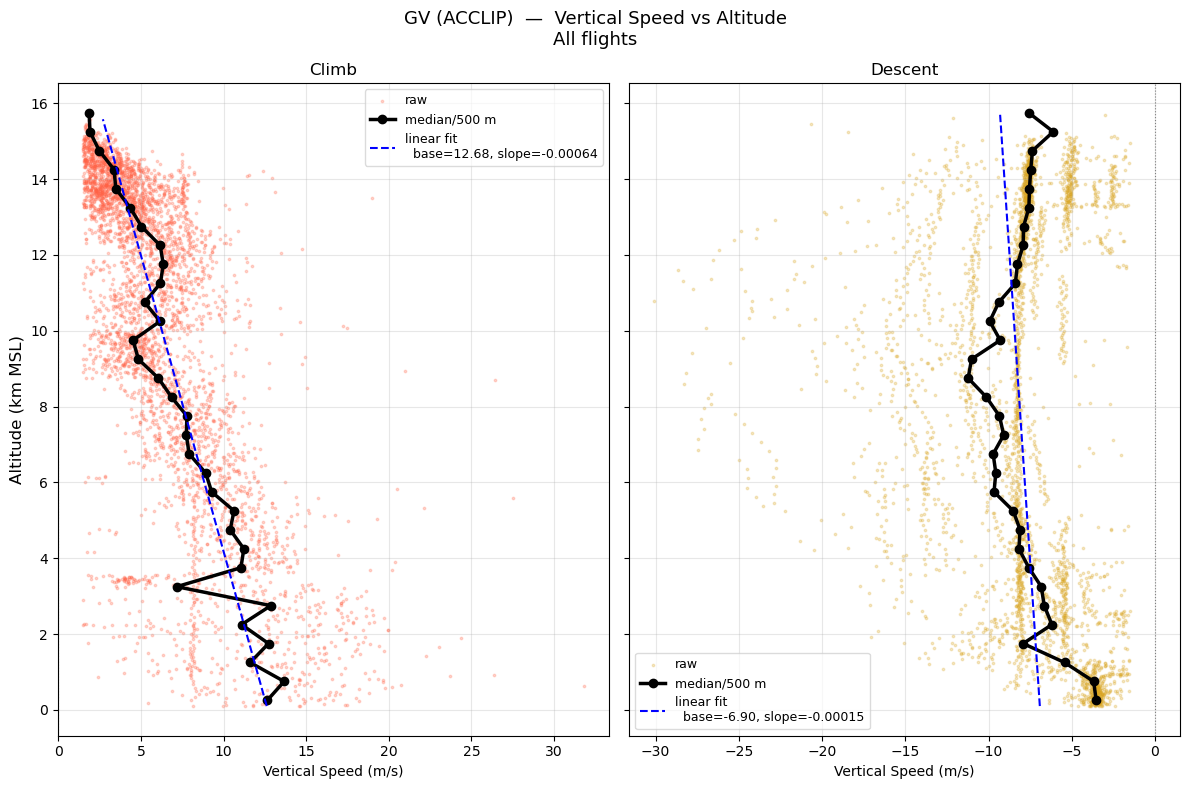

climb   : median vspd = 5.51 m/s,  10th–90th pct = 2.36 – 11.49 m/s
descent : median vspd = -7.76 m/s,  10th–90th pct = -13.73 – -3.47 m/s


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
fig.suptitle('GV (ACCLIP)  —  Vertical Speed vs Altitude\nAll flights', fontsize=13)

for ax, ph, col in zip(axes, ['climb', 'descent'], ['tomato', 'goldenrod']):
    mask = phase == ph
    ax.scatter(vspd_f[mask], alt_f[mask] / 1000.0,
               s=3, alpha=0.25, color=col, label='raw')
    if mask.sum() > 20:
        ac, vc = binned_med(alt_f[mask], vspd_f[mask], ALT_BINS)
        ax.plot(vc, ac / 1000.0,
                color='k', lw=2.5, marker='o', ms=6, label='median/500 m')

    # linear fit for vert_speed_base / vert_speed_per_alt parameterization
    ok = mask & np.isfinite(vspd_f)
    if ok.sum() > 10:
        sl, ic, rv, _, _ = st.linregress(alt_f[ok], vspd_f[ok])
        alt_fit = np.array([alt_f[ok].min(), alt_f[ok].max()])
        ax.plot(ic + sl * alt_fit, alt_fit / 1000.0,
                'b--', lw=1.5, label=f'linear fit\n  base={ic:.2f}, slope={sl:.5f}')

    ax.set_title(ph.capitalize())
    ax.set_xlabel('Vertical Speed (m/s)')
    ax.legend(framealpha=0.7, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(0, color='gray', lw=0.8, ls=':')

axes[0].set_ylabel('Altitude (km MSL)', fontsize=12)

plt.tight_layout()
plt.savefig('GV_vspd_vs_alt.png', dpi=150, bbox_inches='tight')
plt.show()

for ph in ['climb', 'descent']:
    mask = phase == ph
    print(f'{ph:8s}: median vspd = {np.nanmedian(vspd_f[mask]):.2f} m/s,  '
          f'10th–90th pct = {np.nanpercentile(vspd_f[mask],10):.2f} – {np.nanpercentile(vspd_f[mask],90):.2f} m/s')

# Figure 4 – Bank angle (roll) distribution during turns

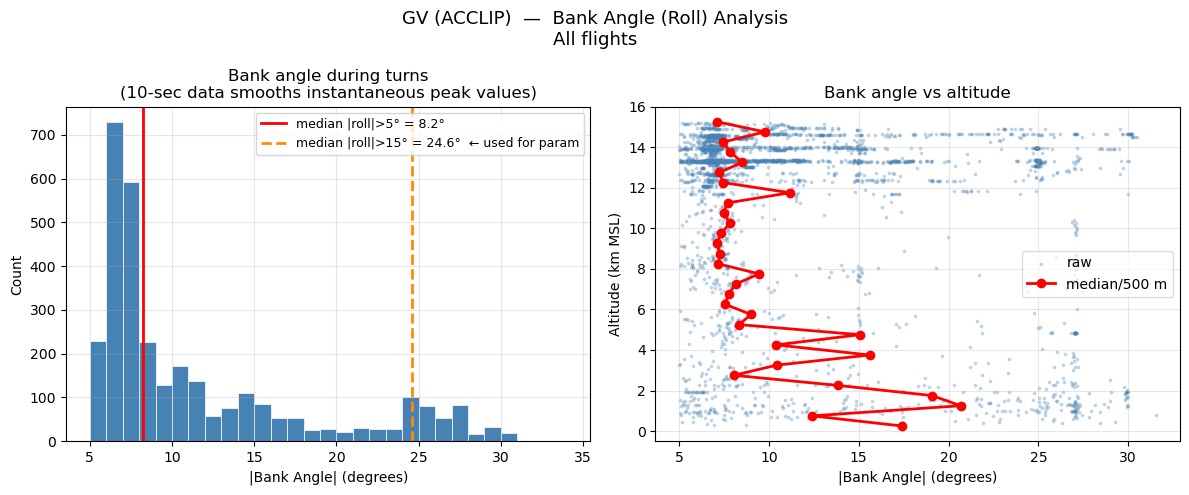

|roll|>5°  — median: 8.2°,  75th pct: 14.6°,  90th pct: 24.9°
|roll|>15° — median: 24.6°  (used for platform turn_bank_angle)


In [9]:
# define 'in a turn' as |roll| > 5 deg
TURN_THRESH = 5.0
in_turn = np.abs(roll_f) > TURN_THRESH
abs_roll_turn = np.abs(roll_f[in_turn & np.isfinite(roll_f)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GV (ACCLIP)  —  Bank Angle (Roll) Analysis\nAll flights', fontsize=13)

# histogram of absolute bank angle when turning
axes[0].hist(abs_roll_turn, bins=np.arange(5, 35, 1), color='steelblue', edgecolor='white', lw=0.5)
axes[0].axvline(np.median(abs_roll_turn), color='red', lw=2,
                label=f'median |roll|>5° = {np.median(abs_roll_turn):.1f}°')
# committed-turn threshold (|roll|>15°) captures peak bank angles despite 10-sec averaging smoothing
TURN_THRESH_PARAM = 15.0
in_turn_param = np.abs(roll_f) > TURN_THRESH_PARAM
abs_roll_param = np.abs(roll_f[in_turn_param & np.isfinite(roll_f)])
axes[0].axvline(np.median(abs_roll_param), color='darkorange', lw=2, ls='--',
                label=f'median |roll|>15° = {np.median(abs_roll_param):.1f}°  ← used for param')
axes[0].set_xlabel('|Bank Angle| (degrees)')
axes[0].set_ylabel('Count')
axes[0].set_title('Bank angle during turns\n(10-sec data smooths instantaneous peak values)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# bank angle vs altitude
ok_turn = in_turn & np.isfinite(roll_f)
axes[1].scatter(np.abs(roll_f[ok_turn]), alt_f[ok_turn] / 1000.0,
                s=3, alpha=0.25, color='steelblue', label='raw')
ac, rc = binned_med(alt_f[ok_turn], np.abs(roll_f[ok_turn]), ALT_BINS)
axes[1].plot(rc, ac / 1000.0, color='red', lw=2, marker='o', ms=6, label='median/500 m')
axes[1].set_xlabel('|Bank Angle| (degrees)')
axes[1].set_ylabel('Altitude (km MSL)')
axes[1].set_title('Bank angle vs altitude')
axes[1].legend(framealpha=0.7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GV_bank_angle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'|roll|>5°  — median: {np.median(abs_roll_turn):.1f}°,  '
      f'75th pct: {np.percentile(abs_roll_turn, 75):.1f}°,  '
      f'90th pct: {np.percentile(abs_roll_turn, 90):.1f}°')
print(f'|roll|>15° — median: {np.median(abs_roll_param):.1f}°  (used for platform turn_bank_angle)')

# Figure 5 – Cruise altitude histogram

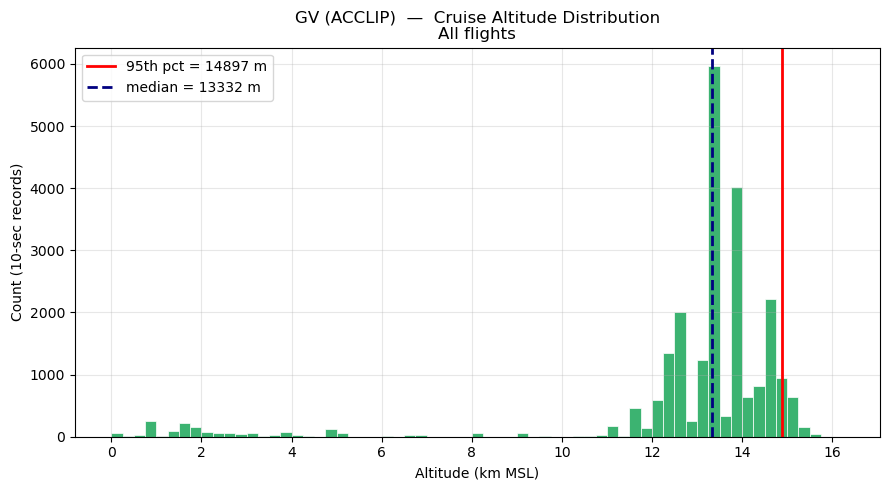

Cruise alt  — median: 13332 m,  95th pct: 14897 m,  max: 15714 m


In [10]:
cruise_mask = phase == 'cruise'
alt_cruise  = alt_f[cruise_mask]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(alt_cruise / 1000.0, bins=np.arange(0, 16.5, 0.25),
        color='mediumseagreen', edgecolor='white', lw=0.5)
ax.axvline(np.percentile(alt_cruise, 95) / 1000.0, color='red', lw=2,
           label=f'95th pct = {np.percentile(alt_cruise, 95):.0f} m')
ax.axvline(np.median(alt_cruise) / 1000.0, color='navy', lw=2, ls='--',
           label=f'median = {np.median(alt_cruise):.0f} m')
ax.set_xlabel('Altitude (km MSL)')
ax.set_ylabel('Count (10-sec records)')
ax.set_title('GV (ACCLIP)  —  Cruise Altitude Distribution\nAll flights')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GV_cruise_alt_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Cruise alt  — median: {np.median(alt_cruise):.0f} m,  '
      f'95th pct: {np.percentile(alt_cruise, 95):.0f} m,  '
      f'max: {alt_cruise.max():.0f} m')

# Derive platform parameters

In [11]:
cruise_mask  = phase == 'cruise'
climb_mask   = phase == 'climb'
descent_mask = phase == 'descent'

from scipy.stats import binned_statistic

# --- max_alt: use 99th percentile of all in-flight altitude ---
max_alt = np.percentile(alt_f, 99)

# --- ground speed parameterization: linear fit cruise gspd vs altitude ---
slope_gs, icept_gs, _, _, _ = st.linregress(alt_f[cruise_mask], gspd_f[cruise_mask])
base_speed    = icept_gs
speed_per_alt = slope_gs

# --- max_speed and max_speed_alt ---
max_speed     = np.percentile(gspd_f, 99)
max_speed_alt = np.median(alt_f[gspd_f >= max_speed * 0.98])

# --- descent_speed_decrease: median speed drop cruise→descent at same altitude ---
shared_bins = np.arange(2000, 14001, 1000)
gs_cruise_bin, _, _ = binned_statistic(alt_f[cruise_mask],  gspd_f[cruise_mask],  'median', bins=shared_bins)
gs_desc_bin,   _, _ = binned_statistic(alt_f[descent_mask], gspd_f[descent_mask], 'median', bins=shared_bins)
descent_speed_decrease = np.nanmedian(gs_cruise_bin - gs_desc_bin)

# --- vertical speed parameterization ---
alt_bins_climb = np.arange(0, 16001, 1000)
vspd_climb_bin, edges, _ = binned_statistic(alt_f[climb_mask], vspd_f[climb_mask], 'median', bins=alt_bins_climb)
centres_climb = 0.5 * (edges[:-1] + edges[1:])
ok_c = np.isfinite(vspd_climb_bin)
slope_vc, icept_vc, r_vc, _, _ = st.linregress(centres_climb[ok_c], vspd_climb_bin[ok_c])

climb_vert_speed   = np.nanmedian(vspd_f[climb_mask])
descent_vert_speed = np.nanmedian(vspd_f[descent_mask])
vert_speed_base    = icept_vc
vert_speed_per_alt = slope_vc

# alt_for_variable_vert_speed: altitude at which binned-median vspd first deviates
# from the overall median by more than 1 m/s (i.e., where altitude-dependence kicks in).
# If the very first bin already varies, set to 0 (linear model applies from ground up).
vspd_climb_bin_c = vspd_climb_bin[ok_c]
centres_c        = centres_climb[ok_c]
deviates = np.abs(vspd_climb_bin_c - climb_vert_speed) > 1.0
dev_alts = centres_c[deviates]
if len(dev_alts) > 0 and dev_alts.min() < 2000:
    alt_for_variable_vert_speed = 0.0   # variable from the start → use linear everywhere
else:
    alt_for_variable_vert_speed = float(dev_alts.min()) if len(dev_alts) > 0 else float(np.nanpercentile(alt_f[climb_mask], 50))

# --- turn bank angle: median of |roll| for committed turns (|roll|>15°) ---
# 10-sec averaging smooths peak values; using |roll|>15° captures actual banked turns
TURN_THRESH_PARAM = 15.0
in_turn_param = np.abs(roll_f) > TURN_THRESH_PARAM
turn_bank_angle = np.median(np.abs(roll_f[in_turn_param & np.isfinite(roll_f)]))

print('=== Derived GV Platform Parameters ===')
print(f'  max_alt                    = {max_alt:.0f}  m')
print(f'  base_speed                 = {base_speed:.1f}  m/s')
print(f'  speed_per_alt              = {speed_per_alt:.5f}  m/s per m')
print(f'  max_speed                  = {max_speed:.1f}  m/s')
print(f'  max_speed_alt              = {max_speed_alt:.0f}  m')
print(f'  descent_speed_decrease     = {descent_speed_decrease:.1f}  m/s')
print(f'  climb_vert_speed           = {climb_vert_speed:.1f}  m/s')
print(f'  descent_vert_speed         = {descent_vert_speed:.1f}  m/s')
print(f'  alt_for_variable_vert_speed= {alt_for_variable_vert_speed:.0f}  m')
print(f'  vert_speed_base            = {vert_speed_base:.2f}  m/s')
print(f'  vert_speed_per_alt         = {vert_speed_per_alt:.6f}  m/s per m')
print(f'  turn_bank_angle            = {turn_bank_angle:.1f}  degrees')

=== Derived GV Platform Parameters ===
  max_alt                    = 15226  m
  base_speed                 = 136.2  m/s
  speed_per_alt              = 0.00750  m/s per m
  max_speed                  = 283.9  m/s
  max_speed_alt              = 13808  m
  descent_speed_decrease     = 3.6  m/s
  climb_vert_speed           = 5.5  m/s
  descent_vert_speed         = -7.8  m/s
  alt_for_variable_vert_speed= 0  m
  vert_speed_base            = 13.30  m/s
  vert_speed_per_alt         = -0.000714  m/s per m
  turn_bank_angle            = 24.6  degrees


# Suggested platform file entry

In [12]:
entry = (
    "{'Platform':'gv',"
    "'names':['gv','GV','G-V','g-v','g v','G V','hiaper','HIAPER','ncar_gv'],\n"
    f"    'max_alt':{max_alt:.0f}.0,"
    f"'base_speed':{base_speed:.1f},"
    f"'speed_per_alt':{speed_per_alt:.4f},\n"
    f"    'max_speed':{max_speed:.1f},"
    f"'max_speed_alt':{max_speed_alt:.0f}.0,"
    f"'descent_speed_decrease':{descent_speed_decrease:.1f},\n"
    f"    'climb_vert_speed':{climb_vert_speed:.1f},"
    f"'descent_vert_speed':{descent_vert_speed:.1f},"
    f"'alt_for_variable_vert_speed':{alt_for_variable_vert_speed:.0f}.0,\n"
    f"    'vert_speed_base':{vert_speed_base:.2f},"
    f"'vert_speed_per_alt':{vert_speed_per_alt:.2e},\n"
    "    'rate_of_turn':None,"
    f"'turn_bank_angle':{turn_bank_angle:.1f},\n"
    "    'warning':False,"
    "'pilot_format':'DD MM',\n"
    "    'preferred_file_format':['foreflight','rdme']}"
)
print(entry)

{'Platform':'gv','names':['gv','GV','G-V','g-v','g v','G V','hiaper','HIAPER','ncar_gv'],
    'max_alt':15226.0,'base_speed':136.2,'speed_per_alt':0.0075,
    'max_speed':283.9,'max_speed_alt':13808.0,'descent_speed_decrease':3.6,
    'climb_vert_speed':5.5,'descent_vert_speed':-7.8,'alt_for_variable_vert_speed':0.0,
    'vert_speed_base':13.30,'vert_speed_per_alt':-7.14e-04,
    'rate_of_turn':None,'turn_bank_angle':24.6,
    'warning':False,'pilot_format':'DD MM',
    'preferred_file_format':['foreflight','rdme']}
